In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

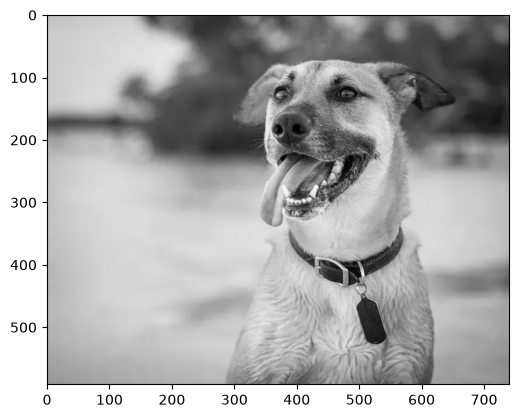

In [3]:
image= cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
cv2.imshow('Original Image', image)

In [4]:
def add_salt_pepper_noise(image, probability = 0.5): 
    noisy = image.copy()
    
    random_values = np.random.rand(*image.shape)
    noisy[random_values < (probability / 2)] = 0  
    noisy[random_values > 1 - (probability / 2)] = 255  
    return noisy

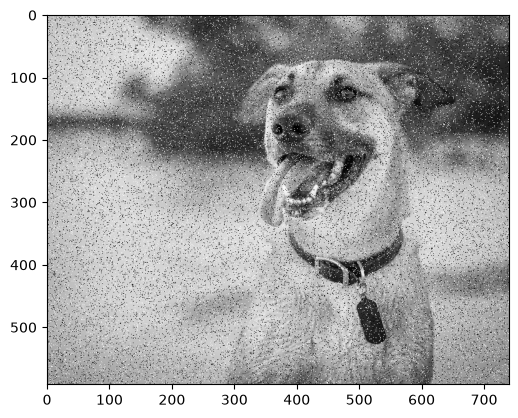

In [5]:
prob = 0.1
noisy = add_salt_pepper_noise(image, prob)
plt.imshow(noisy, cmap='gray')
plt.show()

In [6]:
rows, cols = noisy.shape
result = np.zeros_like(noisy)

# 3x3 Moving Window (Mean Filter)
for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        window = noisy[i-1:i+2, j-1:j+2]   # 3×3 neighborhood
        result[i, j] = np.mean(window)

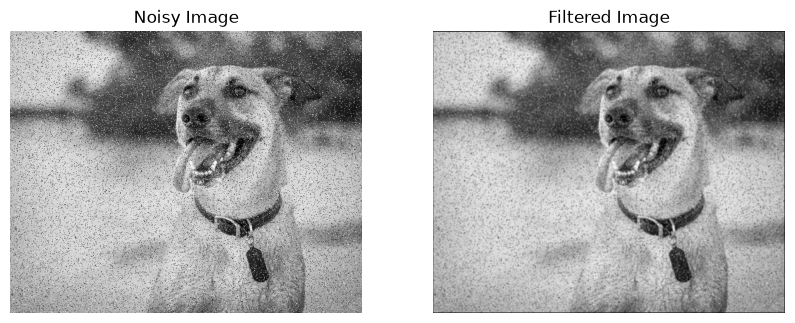

In [7]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title("Filtered Image")
plt.axis("off")

plt.show()
